In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

In [2]:
BASE_DIR = Path().resolve().parent
DATA_PATH = BASE_DIR / "data" / "processed" / "final_dataset.csv"

df = pd.read_csv(DATA_PATH)
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date")

In [3]:
df["stock_return"] = df["close"].pct_change()
df = df.dropna()

In [4]:
lags = [1, 2, 3, 6]  # months

for lag in lags:
    df[f"interest_lag_{lag}"] = df["interest_rate"].shift(lag)
    df[f"inflation_lag_{lag}"] = df["inflation"].shift(lag)
    df[f"gdp_lag_{lag}"] = df["gdp"].shift(lag)

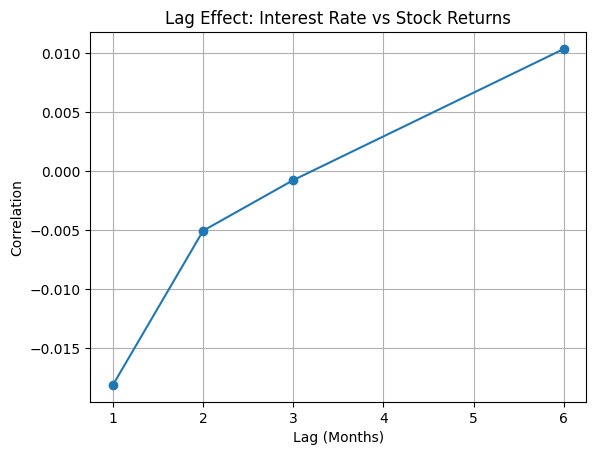

In [5]:
interest_corr = []

for lag in lags:
    corr = df["stock_return"].corr(df[f"interest_lag_{lag}"])
    interest_corr.append(corr)

plt.plot(lags, interest_corr, marker="o")
plt.title("Lag Effect: Interest Rate vs Stock Returns")
plt.xlabel("Lag (Months)")
plt.ylabel("Correlation")
plt.grid()
plt.show()

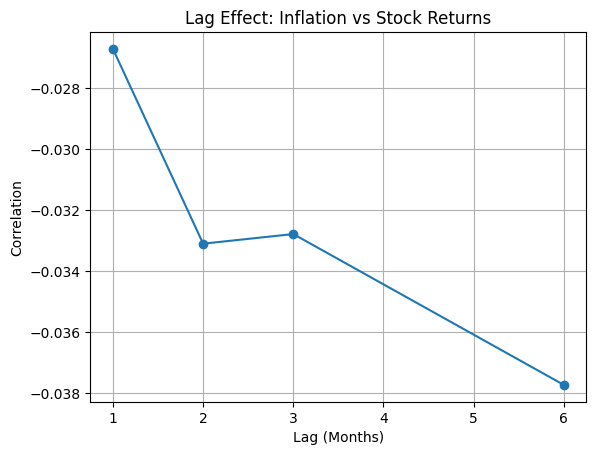

In [6]:
inflation_corr = []

for lag in lags:
    corr = df["stock_return"].corr(df[f"inflation_lag_{lag}"])
    inflation_corr.append(corr)

plt.plot(lags, inflation_corr, marker="o")
plt.title("Lag Effect: Inflation vs Stock Returns")
plt.xlabel("Lag (Months)")
plt.ylabel("Correlation")
plt.grid()
plt.show()

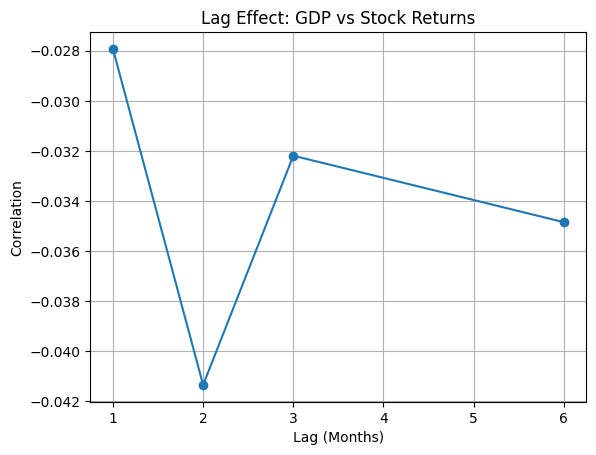

In [7]:
gdp_corr = []

for lag in lags:
    corr = df["stock_return"].corr(df[f"gdp_lag_{lag}"])
    gdp_corr.append(corr)

plt.plot(lags, gdp_corr, marker="o")
plt.title("Lag Effect: GDP vs Stock Returns")
plt.xlabel("Lag (Months)")
plt.ylabel("Correlation")
plt.grid()
plt.show()